# Análisis exploratorio de los datos (EDA)

# Preparación del dataset

In [ ]:
#Importación de librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [ ]:
#Importación del csv
!wget https://raw.githubusercontent.com/Alferez36/Inteligencia-Artificial/refs/heads/main/diabetes_dataset.csv

--2026-01-08 18:11:20--  https://raw.githubusercontent.com/Alferez36/Inteligencia-Artificial/refs/heads/main/diabetes_dataset.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14365521 (14M) [text/plain]
Saving to: ‘diabetes_dataset.csv’

diabetes_dataset.cs 100%[===================>]  13.70M  43.0MB/s    in 0.3s    

2026-01-08 18:11:21 (43.0 MB/s) - ‘diabetes_dataset.csv’ saved [14365521/14365521]



In [ ]:
df = pd.read_csv('diabetes_dataset.csv')
df.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


## Limpieza y Pre-procesamiento inicial de los datos

### Identificación de los valores nulos
No hay valores nulos, por lo que no faltan datos en la BBDD.

In [ ]:
df.isnull().sum()

,0
age,0
gender,0
ethnicity,0
education_level,0
income_level,0
employment_status,0
smoking_status,0
alcohol_consumption_per_week,0
physical_activity_minutes_per_week,0
diet_score,0


Además, hay algunos valores en los que un 0 es físicamente imposible. Sin embargo, confirmamos que todas las columnas en las que hay 0, este valor puede tener sentido.

In [ ]:
(df == 0).sum()

,0
age,0
gender,0
ethnicity,0
education_level,0
income_level,0
employment_status,0
smoking_status,0
alcohol_consumption_per_week,13535
physical_activity_minutes_per_week,14
diet_score,46


### Identificación de Outliers


Hay algunos valores altos, pero tienen sentido dentro de una base de datos con pacientes diabéticos. Por ejemplo, un valor de 350 de triglicéridos es elevado, pero dentro de los valores posibles.

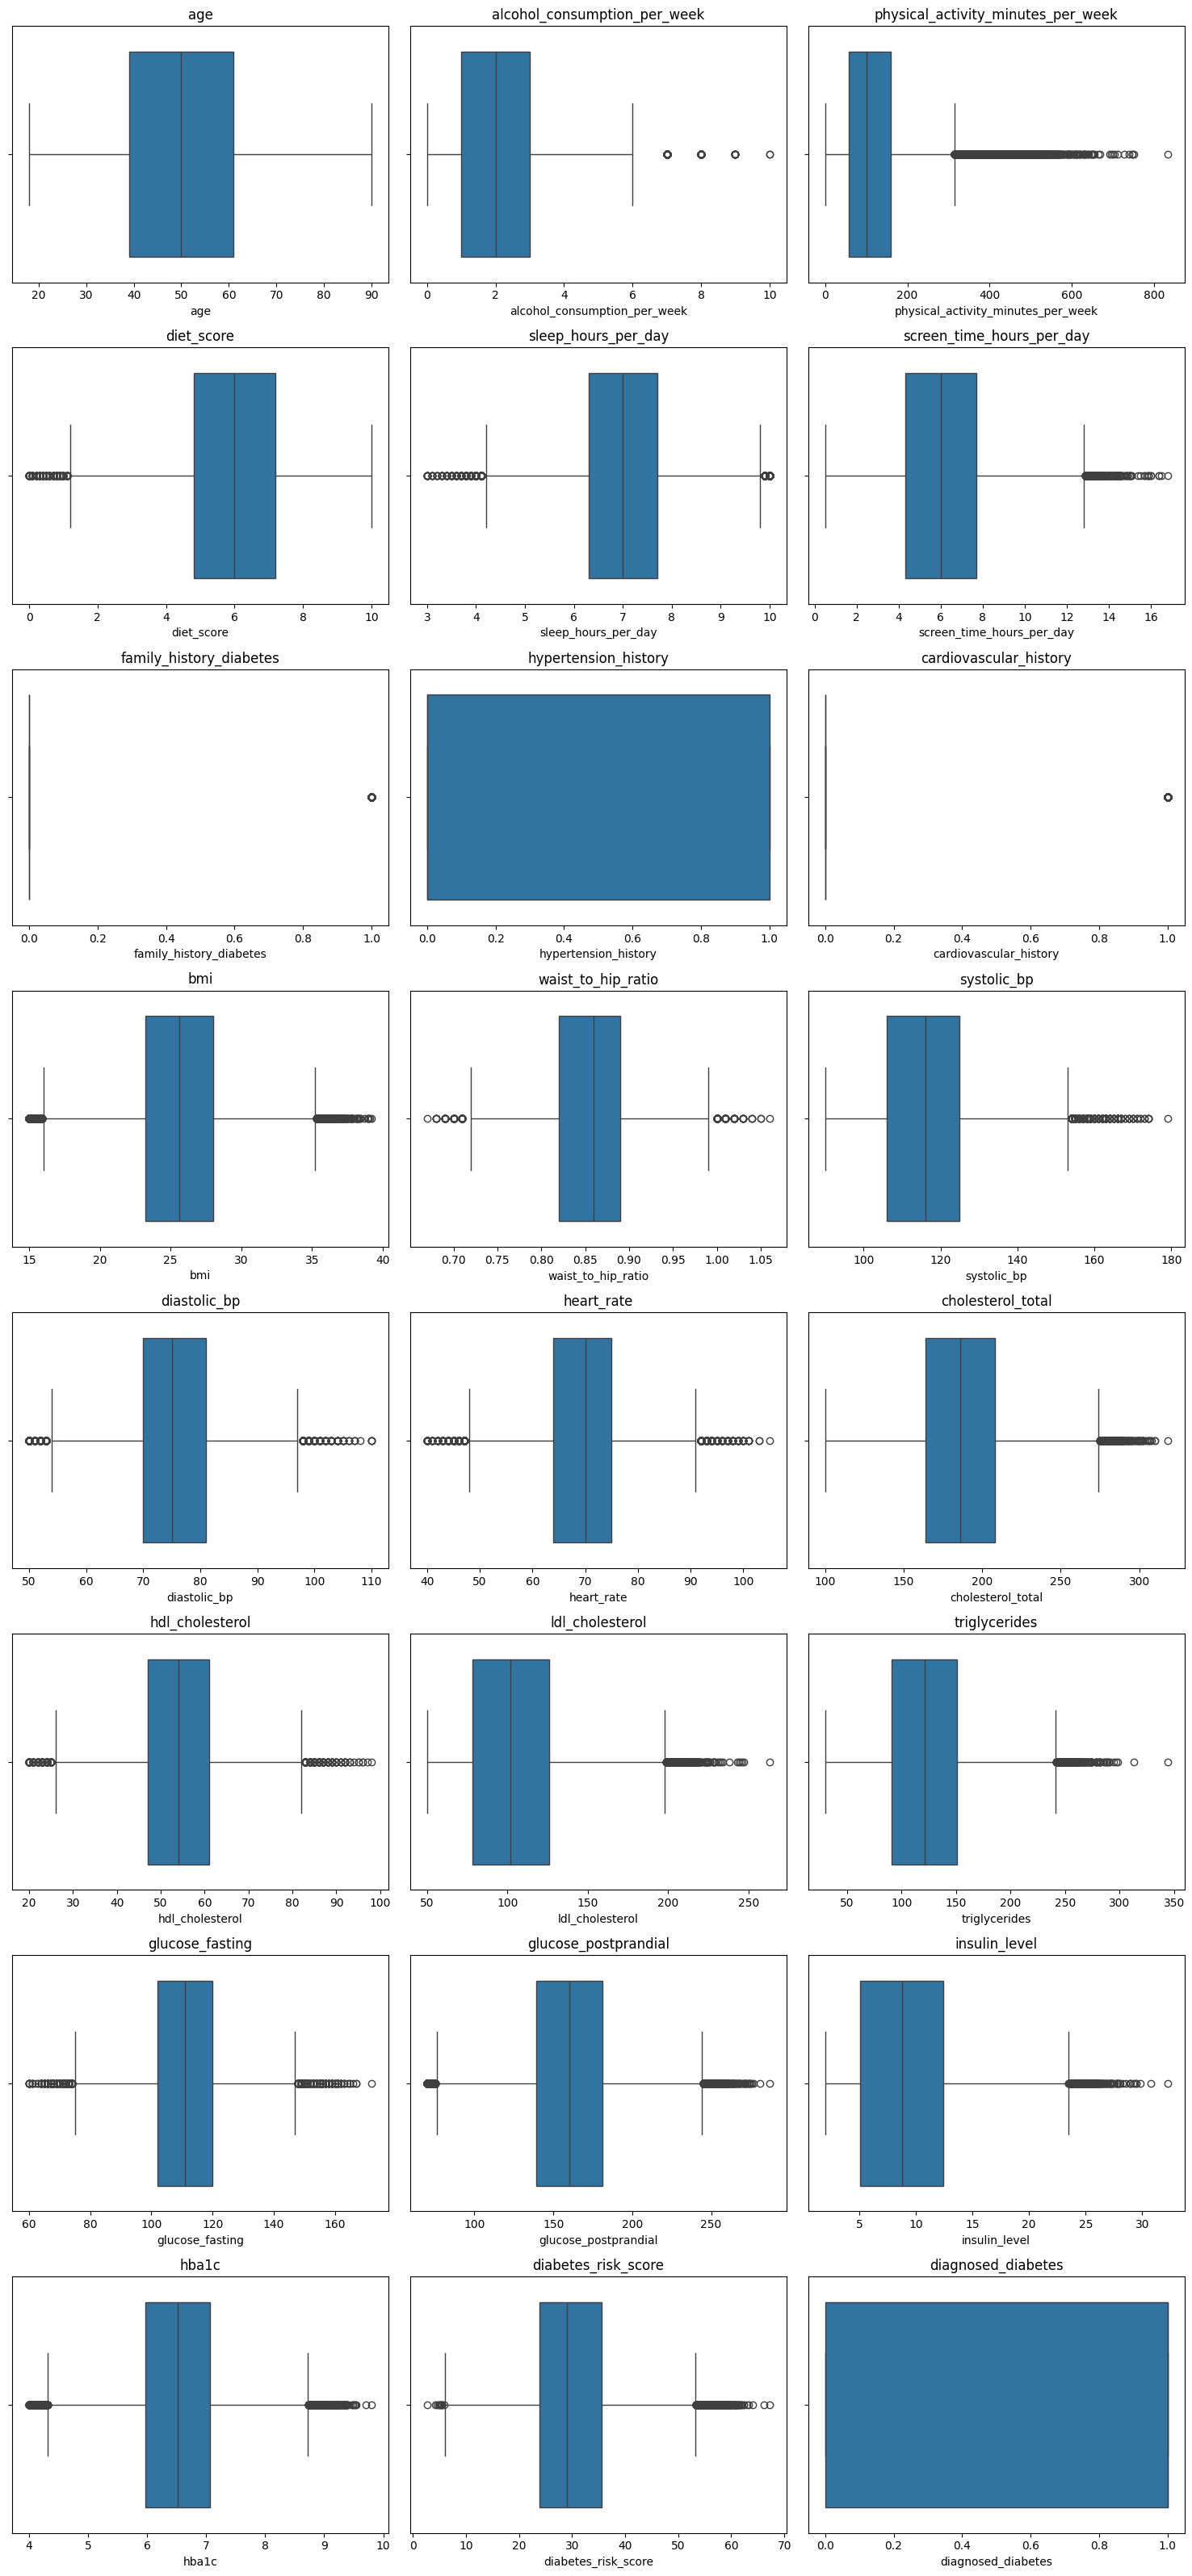

In [ ]:
#Boxplot para todas las columnas con valores numéricos
cols_numericas = df.select_dtypes(include=['number']).columns
n_filas = math.ceil(len(cols_numericas) / 3)

fig, axes = plt.subplots(n_filas, 3, figsize=(15,n_filas*4))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Introducción al dataset

In [ ]:
total_pacientes = len(df)
print(f"Total de pacientes: {total_pacientes}")

Total de pacientes: 100000


In [ ]:
gender_diff = df['diagnosed_diabetes'].value_counts(normalize="True").mul(100).round(4).astype(str) + ' %'
print(gender_diff)

diagnosed_diabetes
1    59.998 %
0    40.002 %
Name: proportion, dtype: object


In [ ]:
stage = df['diabetes_stage'].value_counts(normalize="True").mul(100).round(4).astype(str) + ' %'
print(stage)

diabetes_stage
Type 2          59.774 %
Pre-Diabetes    31.845 %
No Diabetes      7.981 %
Gestational      0.278 %
Type 1           0.122 %
Name: proportion, dtype: object


Para la predicción binaria de la diabetes, el dataset está balanceado. Sin embargo, hay un **desbalance de clases** alto con Gestacional y Tipo 1 ya que juntas no llegan al 0.5% de los casos. Por tanto, el modelo va a dar problemas en la predicción del estado. A partir de estas conclusiones, sugiero centrar el modelo en la predicción del diagnóstico, no del estado. Además, el dataset no incluye a las personas embarazadas. Sería de utilidad para saber las que lo desarrollaron durante el embarazo comparado con las que lo tenían previamente.  

Este desbalanceo de los datos tiene sentido dentro de la realidad. Más del 90% de los diabéticos padece de tipo 2.

https://idf.org/es/about-diabetes/diabetes-facts-figures/

In [ ]:
df.describe()

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
count,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50.12041,2.003670,118.911640,5.994787,6.997818,5.996468,0.219410,0.250800,0.079200,25.612653,...,185.978110,54.042790,103.000430,121.462650,111.11712,160.035050,9.061242,6.520776,30.222362,0.599980
std,15.60460,1.417779,84.409662,1.780954,1.094622,2.468406,0.413849,0.433476,0.270052,3.586705,...,32.013005,10.267374,33.390256,43.372619,13.59561,30.935472,4.954060,0.813921,9.061505,0.489904
min,18.00000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000,0.000000,0.000000,15.000000,...,100.000000,20.000000,50.000000,30.000000,60.00000,70.000000,2.000000,4.000000,2.700000,0.000000
25%,39.00000,1.000000,57.000000,4.800000,6.300000,4.300000,0.000000,0.000000,0.000000,23.200000,...,164.000000,47.000000,78.000000,91.000000,102.00000,139.000000,5.090000,5.970000,23.800000,0.000000
50%,50.00000,2.000000,100.000000,6.000000,7.000000,6.000000,0.000000,0.000000,0.000000,25.600000,...,186.000000,54.000000,102.000000,121.000000,111.00000,160.000000,8.790000,6.520000,29.000000,1.000000
75%,61.00000,3.000000,160.000000,7.200000,7.700000,7.700000,0.000000,1.000000,0.000000,28.000000,...,208.000000,61.000000,126.000000,151.000000,120.00000,181.000000,12.450000,7.070000,35.600000,1.000000
max,90.00000,10.000000,833.000000,10.000000,10.000000,16.800000,1.000000,1.000000,1.000000,39.200000,...,318.000000,98.000000,263.000000,344.000000,172.00000,287.000000,32.220000,9.800000,67.200000,1.000000


## Perfil demográfico

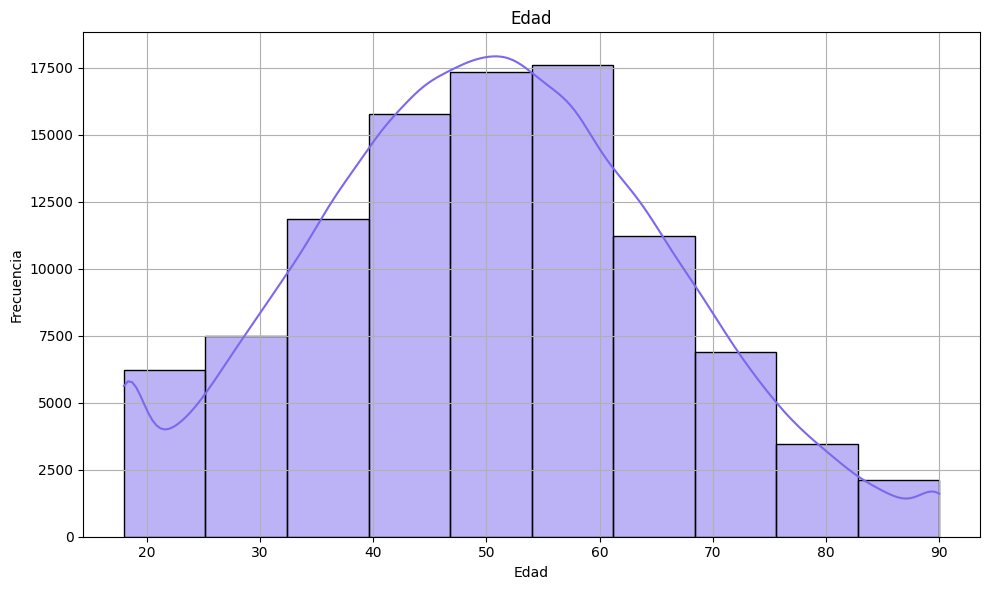

In [ ]:
plt.figure(figsize = (10,6))
sns.histplot(df["age"], bins=10, kde=True,
color='mediumslateblue')
plt.title("Edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
gender_diff = df['gender'].value_counts(normalize="True").mul(100).round(4).astype(str) + ' %'
print(gender_diff)

gender
Female    50.216 %
Male      47.771 %
Other      2.013 %
Name: proportion, dtype: object


In [ ]:
diff_etnia = df['ethnicity'].value_counts(normalize="True").mul(100).round(4).astype(str) + ' %'
print(diff_etnia)

ethnicity
White       44.997 %
Hispanic    20.103 %
Black       17.986 %
Asian       11.865 %
Other        5.049 %
Name: proportion, dtype: object


In [ ]:
diff_nivel_educacion = df['education_level'].value_counts(normalize="True").mul(100).round(4).astype(str) + ' %'
print(diff_nivel_educacion)

education_level
Highschool      44.891 %
Graduate        35.037 %
Postgraduate    14.972 %
No formal          5.1 %
Name: proportion, dtype: object


In [ ]:
diff_income_level = df['income_level'].value_counts(normalize="True").mul(100).round(4).astype(str) + ' %'
print(diff_income_level)

income_level
Middle          35.152 %
Lower-Middle     25.15 %
Upper-Middle    19.866 %
Low              14.83 %
High             5.002 %
Name: proportion, dtype: object


In [ ]:
diff_empleo = df['employment_status'].value_counts(normalize="True").mul(100).round(4).astype(str) + ' %'
print(diff_empleo)

employment_status
Employed      60.175 %
Retired       21.761 %
Unemployed    11.918 %
Student        6.146 %
Name: proportion, dtype: object


### Etnia

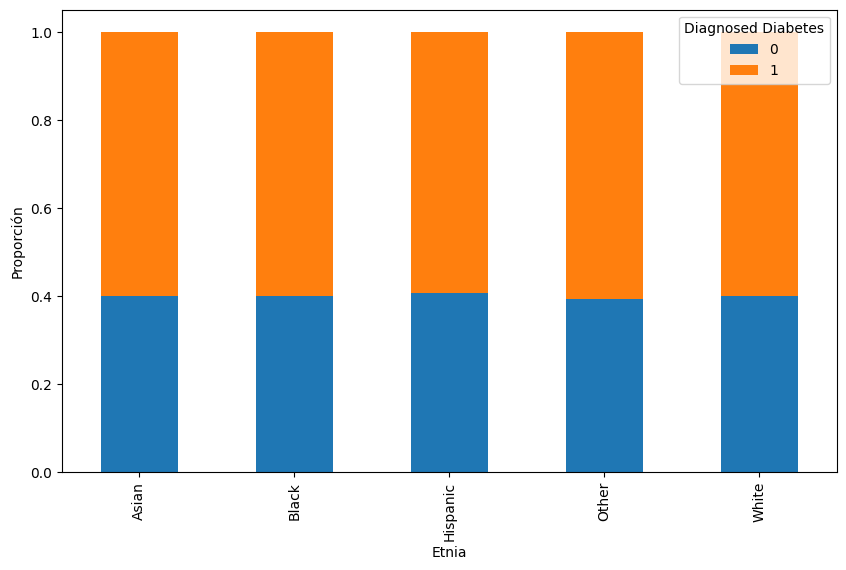

In [ ]:
ct = pd.crosstab(df['ethnicity'], df['diagnosed_diabetes'], normalize='index')

ct.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.ylabel('Proporción')
plt.xlabel('Etnia')
plt.legend(title='Diagnosed Diabetes', loc='upper right')
plt.show()

In [ ]:
print(ct)

diagnosed_diabetes         0         1
ethnicity                             
Asian               0.399241  0.600759
Black               0.398588  0.601412
Hispanic            0.406059  0.593941
Other               0.392355  0.607645
White               0.398960  0.601040


# Estilo de vida

Las recomendaciones de la OMS recomiendan por lo menos de 150 a 300 minutos de actividad física a la semana para prevenir y ayudar enfermedades como la diabetes.   

https://www.who.int/es/news/item/25-11-2020-every-move-counts-towards-better-health-says-who

In [ ]:
df_cumplen_ejercicio = df[(df['physical_activity_minutes_per_week'] >= 150) & (df['physical_activity_minutes_per_week'] <= 300)]
total_cumplen_ejercicio=len(df_cumplen_ejercicio)
print(f"Cumplen el ejercicio: {total_cumplen_ejercicio}")
porcentaje_cumplen_ejercicio = (total_cumplen_ejercicio / total_pacientes) * 100
print(f"Porcentaje de pacientes que cumplen con el ejercicio: {porcentaje_cumplen_ejercicio:.2f}%")

Cumplen el ejercicio: 24584
Porcentaje de pacientes que cumplen con el ejercicio: 24.58%


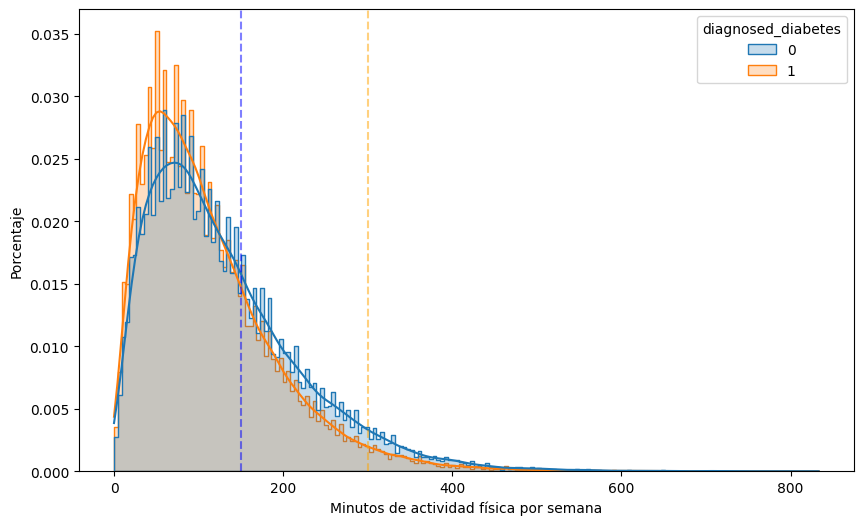

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(data=df, x='physical_activity_minutes_per_week',
             hue='diagnosed_diabetes',
             stat="probability",
             common_norm=False,
             kde=True,
             element="step")

plt.xlabel('Minutos de actividad física por semana')
plt.ylabel('Porcentaje')
plt.axvline(x=150, color='blue', linestyle='--', alpha=0.5, label='Límite bajo')
plt.axvline(x=300, color='orange', linestyle='--', alpha=0.5, label='Límite alto')
plt.show()

Se recomienda dormir entre 6 y 9 horas.

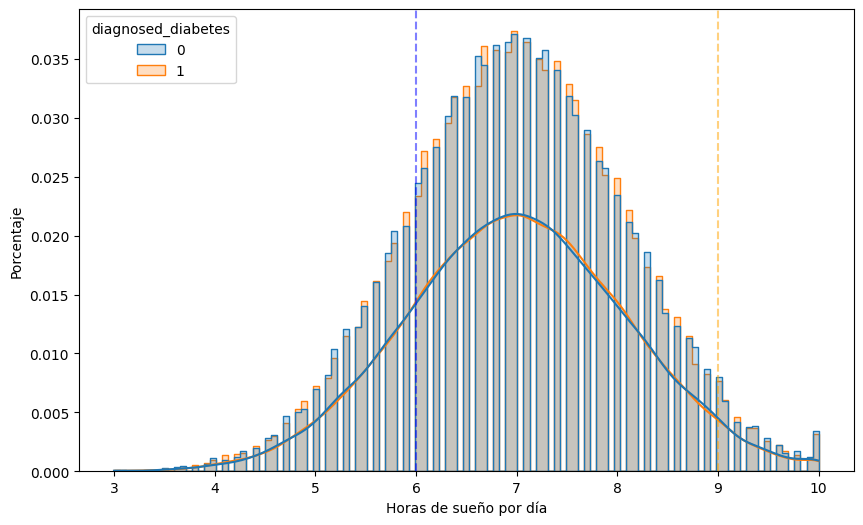

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(data=df, x='sleep_hours_per_day',
             hue='diagnosed_diabetes',
             stat="probability",
             common_norm=False,
             kde=True,
             element="step")

plt.xlabel('Horas de sueño por día')
plt.ylabel('Porcentaje')
plt.axvline(x=6, color='blue', linestyle='--', alpha=0.5, label='Límite bajo')
plt.axvline(x=9, color='orange', linestyle='--', alpha=0.5, label='Límite alto')
plt.show()

Dieta

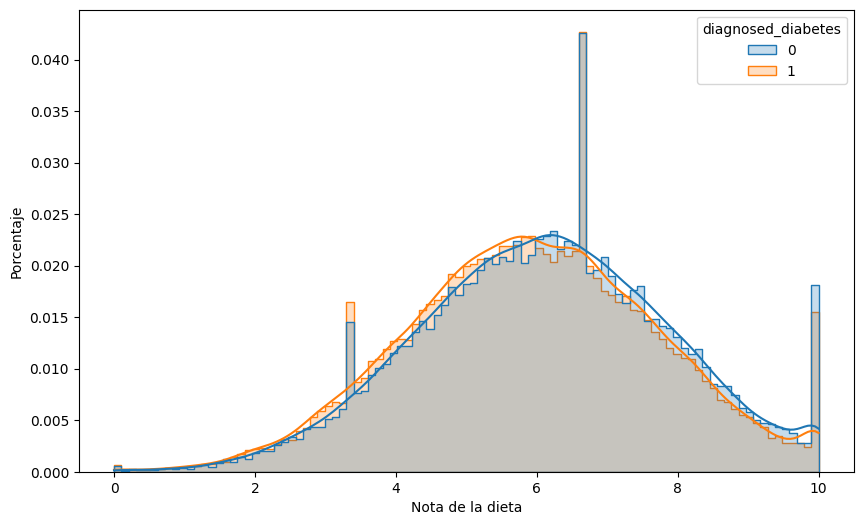

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(data=df, x='diet_score',
             hue='diagnosed_diabetes',
             stat="probability",
             common_norm=False,
             kde=True,
             element="step")

plt.xlabel('Nota de la dieta')
plt.ylabel('Porcentaje')
plt.show()

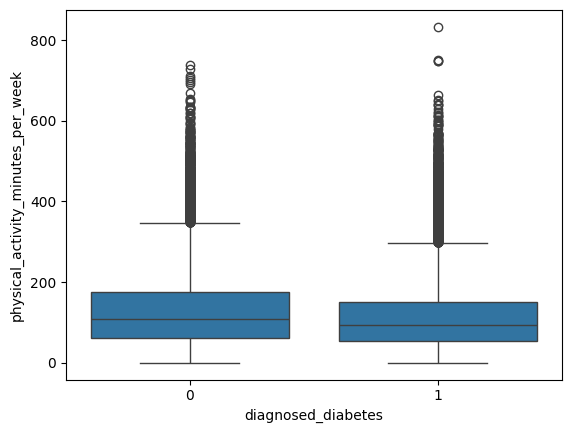

In [ ]:
sns.boxplot(
    data=df, x='diagnosed_diabetes',
    y='physical_activity_minutes_per_week'
)
plt.show()

### Alcohol
La ingesta de alcohol aumenta la síntesis de triglicéricos, frecuente en muchos diabéticos.
https://diabetesmadrid.org/alcohol-y-diabetes/

In [ ]:
corr_alcohol_trig = df['alcohol_consumption_per_week'].corr(df['triglycerides'])
print(f"Correlación entre Alcohol y Triglicéridos: {corr_alcohol_trig:.4f}")

Correlación entre Alcohol y Triglicéridos: 0.1267


## Factores de riesgo


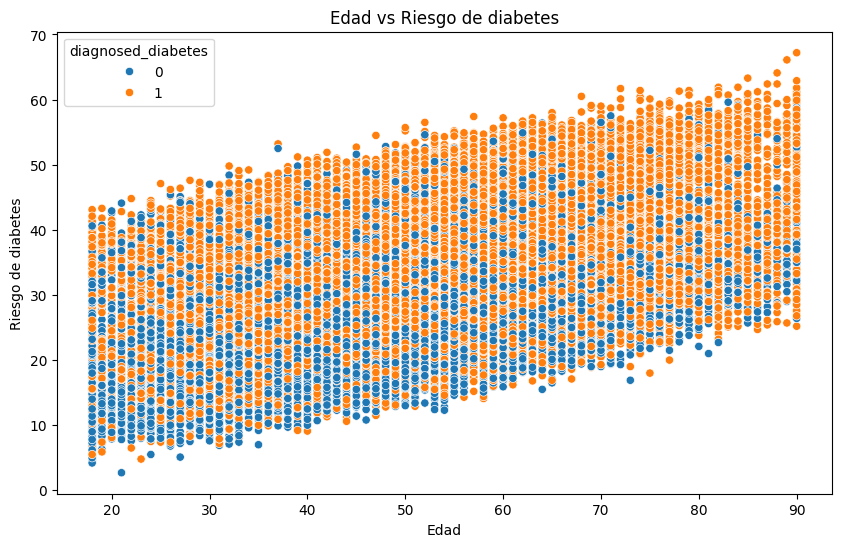

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='age',y='diabetes_risk_score',hue='diagnosed_diabetes')
plt.title('Edad vs Riesgo de diabetes')
plt.xlabel('Edad')
plt.ylabel('Riesgo de diabetes')
plt.show()

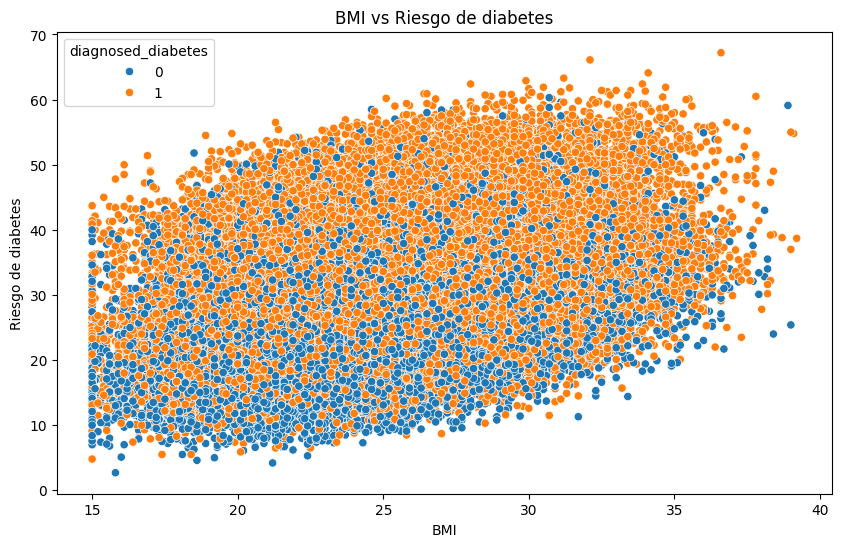

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='bmi',y='diabetes_risk_score',hue='diagnosed_diabetes')
plt.title('BMI vs Riesgo de diabetes')
plt.xlabel('BMI')
plt.ylabel('Riesgo de diabetes')
plt.show()

In [ ]:
df['bmi_clas'] = pd.cut(df['bmi'], bins=[0, 18.5, 25, 30, 100], labels=['Bajo', 'Normal', 'Sobrepeso', 'Obesidad'])
pd.crosstab(df['bmi_clas'], df['diagnosed_diabetes'], normalize='index') * 100

diagnosed_diabetes,0,1
bmi_clas,,
Bajo,50.183150,49.816850
Normal,43.856626,56.143374
Sobrepeso,37.960215,62.039785
Obesidad,31.611475,68.388525


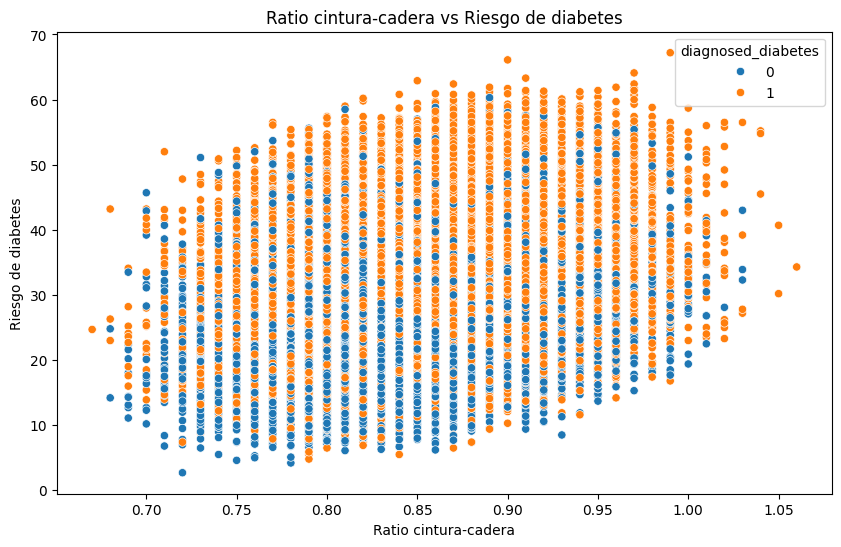

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='waist_to_hip_ratio',y='diabetes_risk_score',hue='diagnosed_diabetes')
plt.title('Ratio cintura-cadera vs Riesgo de diabetes')
plt.xlabel('Ratio cintura-cadera')
plt.ylabel('Riesgo de diabetes')
plt.show()

Durante el entrenamiento del modelo C del Random Forest, se identificaron que las variables más importantes para la predicción eran la Actividad Física, el IMC y la Edad, seguidas por el colesterol total, la sistólica y los trigliceridos.

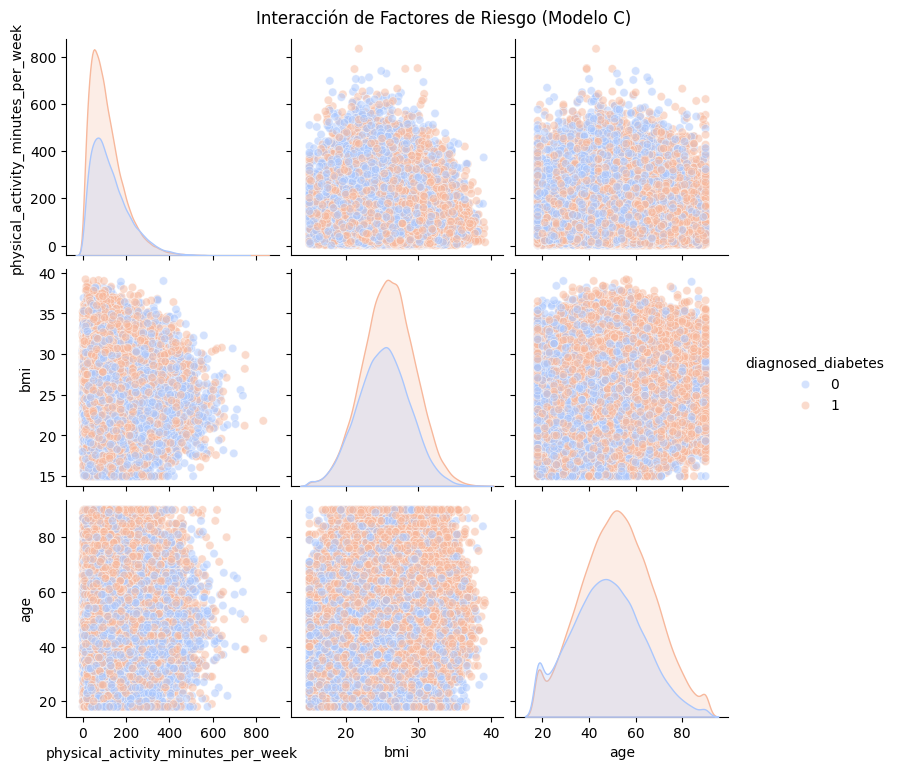

In [ ]:
cols_riesgo = ['physical_activity_minutes_per_week', 'bmi', 'age', 'diagnosed_diabetes']

sns.pairplot(df[cols_riesgo], hue='diagnosed_diabetes', palette='coolwarm', plot_kws={'alpha':0.5})
plt.suptitle("Interacción de Factores de Riesgo (Modelo C)", y=1.02)
plt.show()

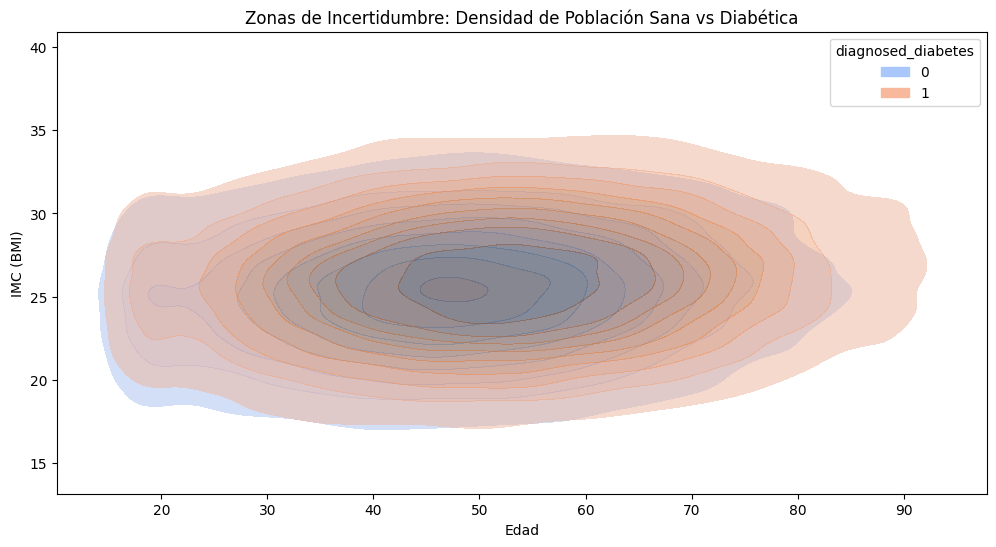

/tmp/ipython-input-1362013375.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_risk = df.groupby(['bmi_level', 'activity_level'])['diagnosed_diabetes'].mean().unstack()


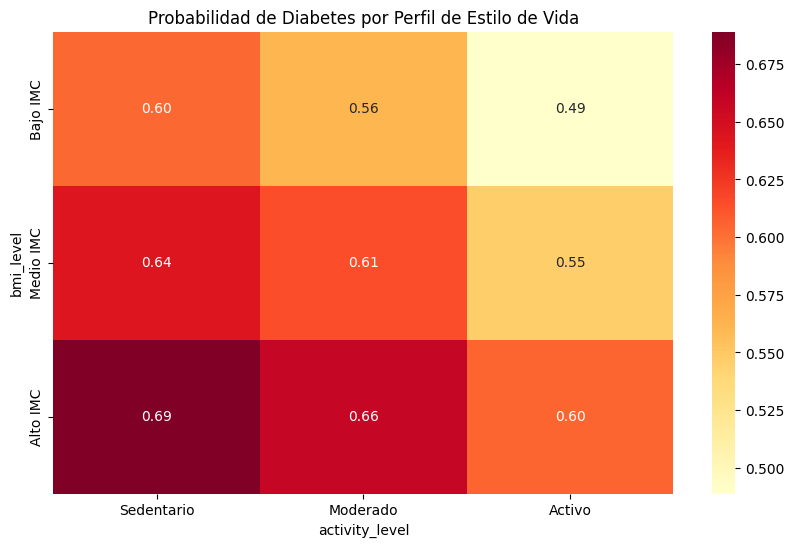

In [ ]:
df['bmi_level'] = pd.qcut(df['bmi'], 3, labels=['Bajo IMC', 'Medio IMC', 'Alto IMC'])
df['activity_level'] = pd.qcut(df['physical_activity_minutes_per_week'], 3,
                               labels=['Sedentario', 'Moderado', 'Activo'])

# 2. Visualización de Densidad 2D (KDE) para identificar el Overlap
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df, x="age", y="bmi", hue="diagnosed_diabetes",
            fill=True, alpha=0.5, palette='coolwarm')
plt.title('Zonas de Incertidumbre: Densidad de Población Sana vs Diabética')
plt.xlabel('Edad')
plt.ylabel('IMC (BMI)')
plt.show()

In [ ]:
#Heatmap de riesgo
heat_riesgo = df.groupby(['bmi_level', 'activity_level'])['diagnosed_diabetes'].mean().unstack()

plt.figure(figsize=(10, 6))
sns.heatmap(heat_riesgo, annot=True, fmt=".2f")
plt.title('Probabilidad de Diabetes por Perfil de Estilo de Vida')
plt.show()

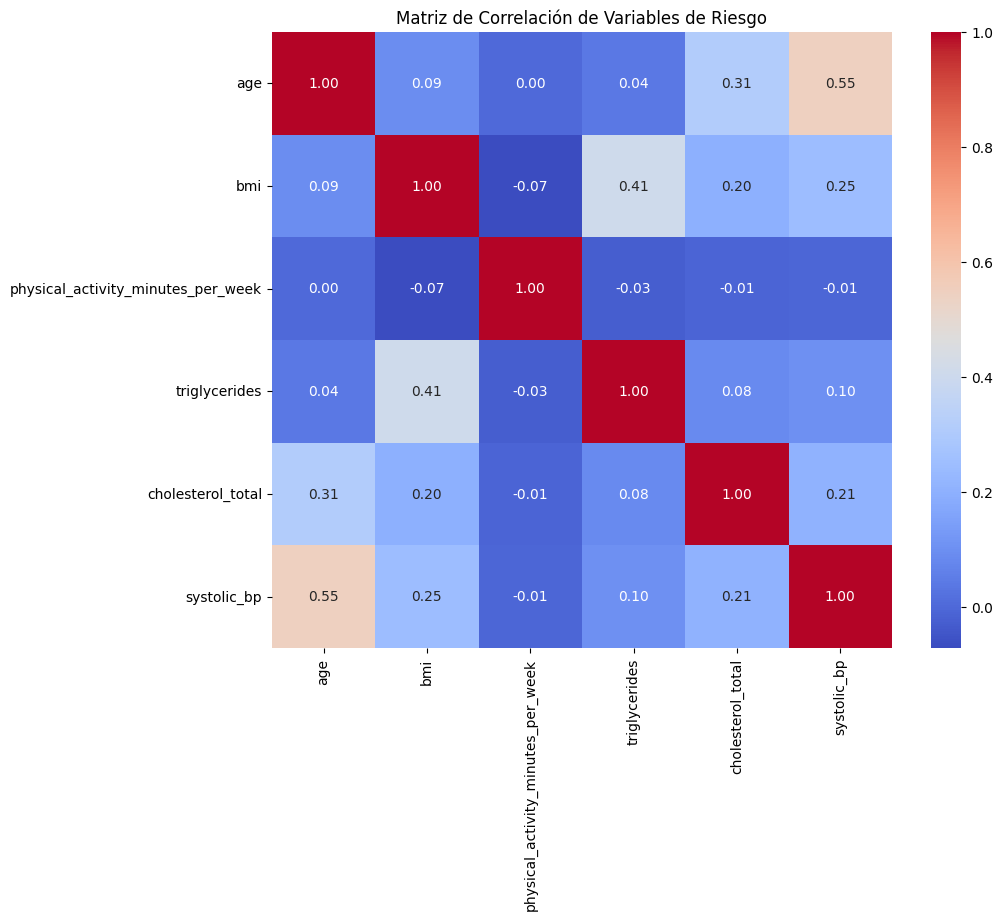

In [ ]:
var_riesgo = ['age', 'bmi', 'physical_activity_minutes_per_week',
                'triglycerides', 'cholesterol_total', 'systolic_bp']

plt.figure(figsize=(10, 8))
sns.heatmap(df[var_riesgo].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación de Variables de Riesgo")
plt.show()

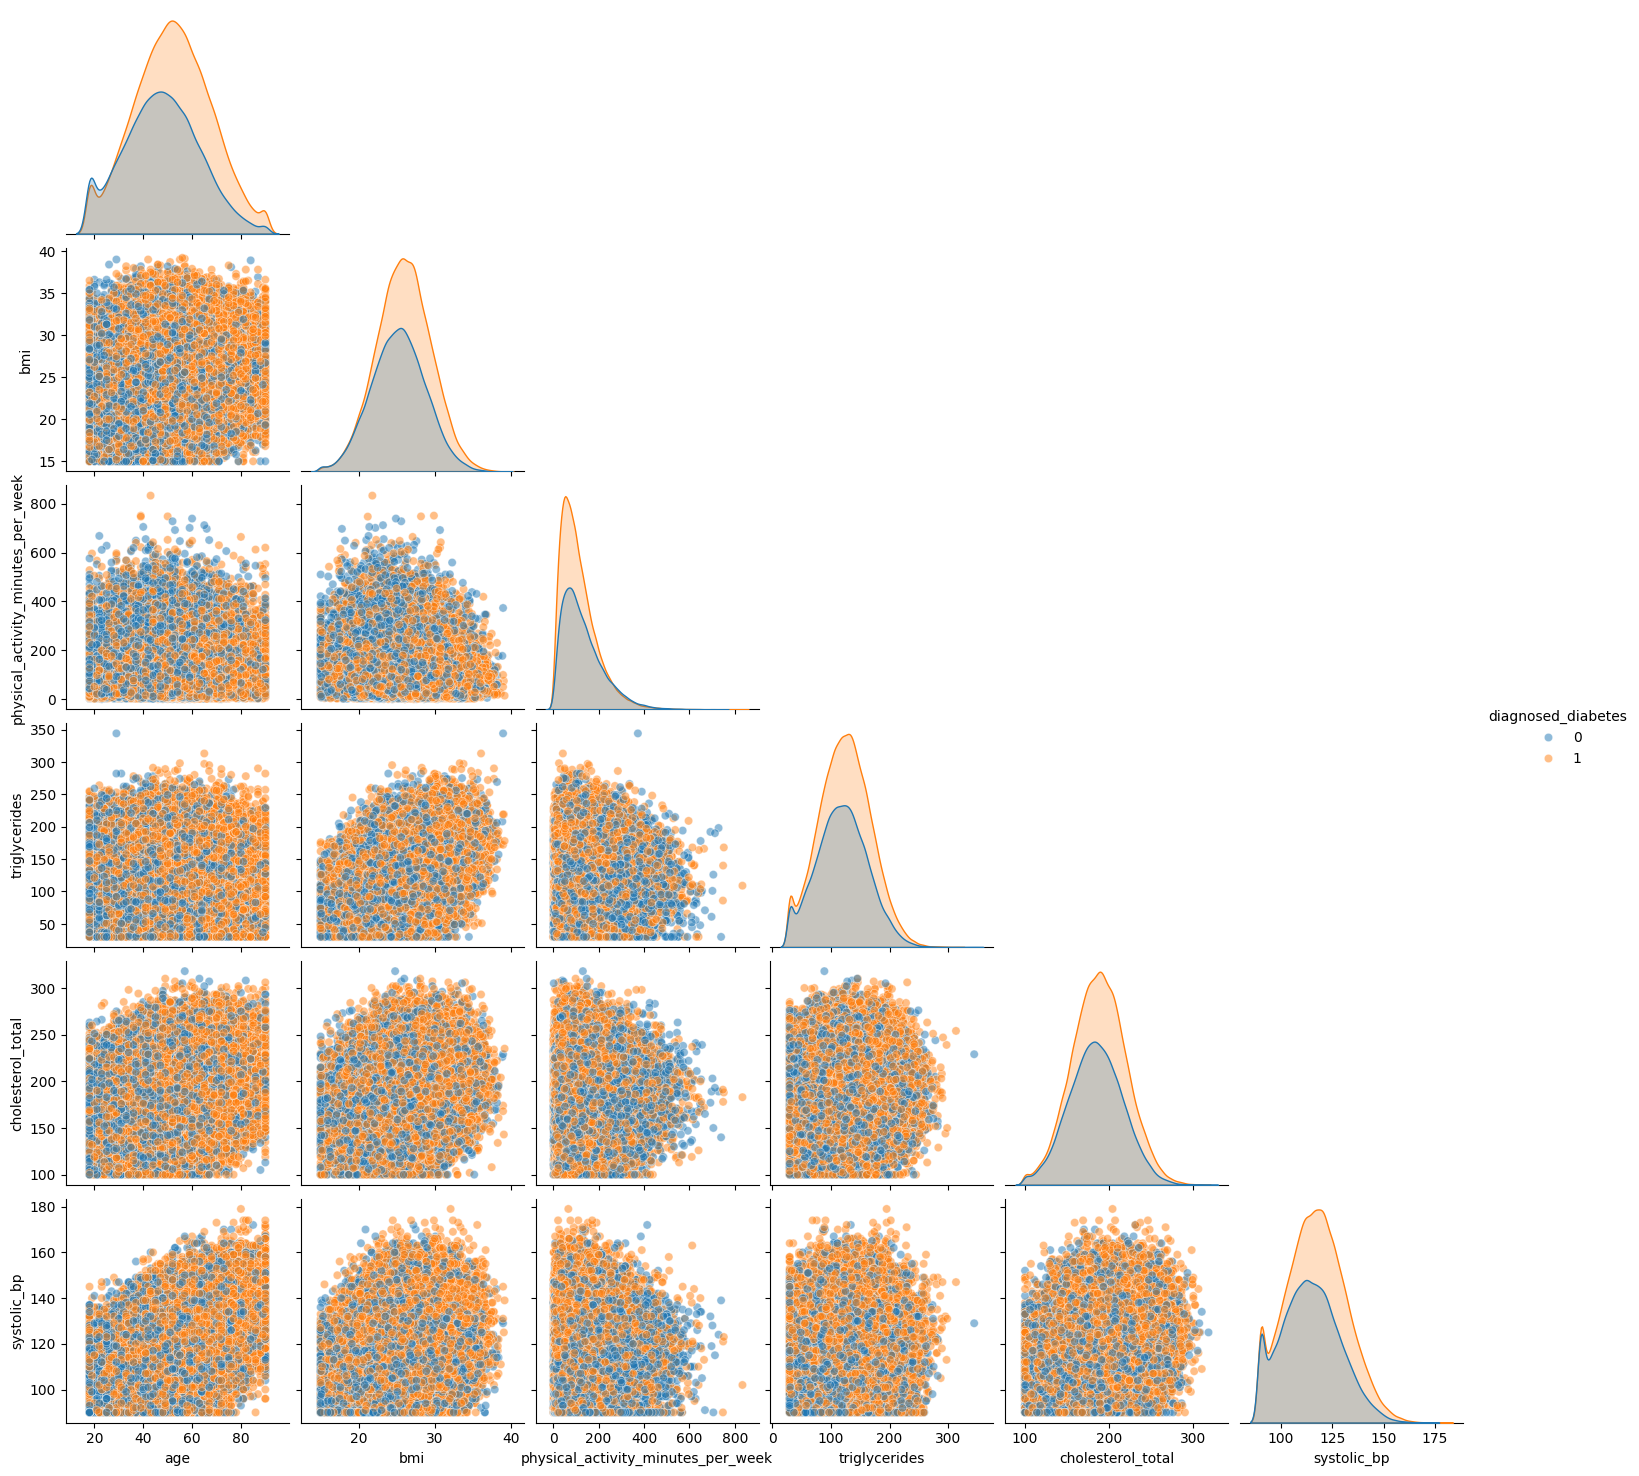

In [ ]:
sns.pairplot(df[var_riesgo + ['diagnosed_diabetes']], hue='diagnosed_diabetes', corner=True, diag_kind='kde', plot_kws={'alpha': 0.5})
plt.show()

# Glucosa e insulina
Correlación entre las variables.

<Axes: >

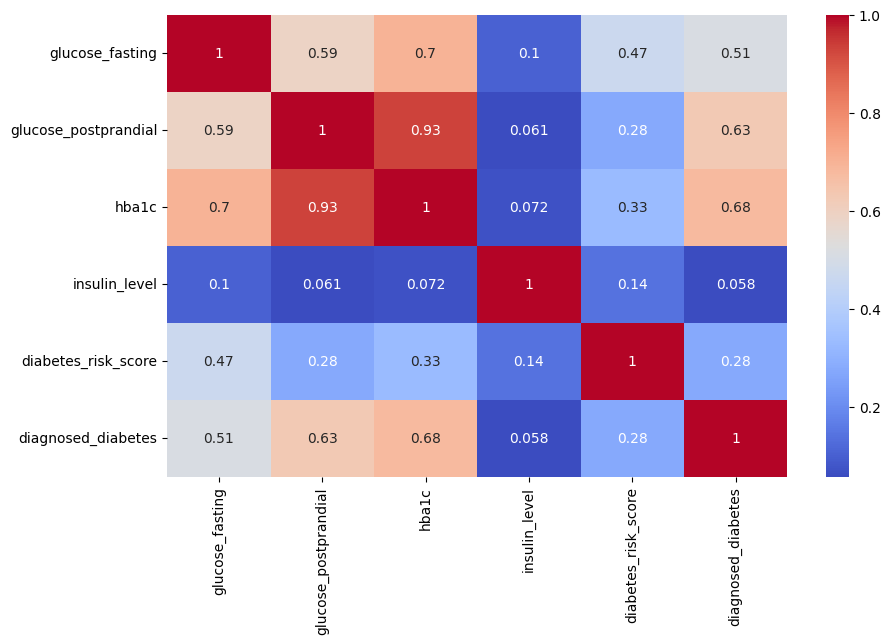

In [ ]:
glucemia = ['glucose_fasting', 'glucose_postprandial', 'hba1c', 'insulin_level', 'diabetes_risk_score', 'diagnosed_diabetes']

plt.figure(figsize=(10, 6))
sns.heatmap(df[glucemia].corr(), annot=True, cmap='coolwarm')

El nivel de insulina (insulin_level) tiene una correlación cercana a cero con el resto de las variables.

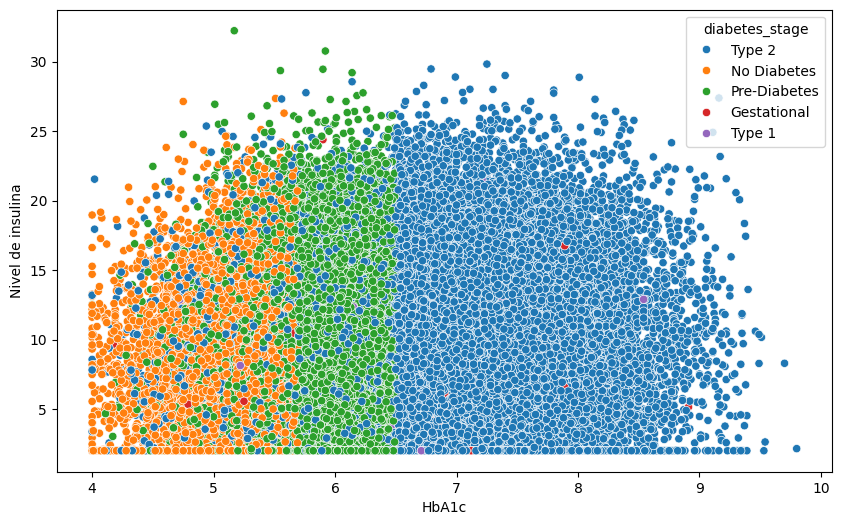

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='hba1c',y='insulin_level',hue='diabetes_stage')
plt.xlabel('HbA1c')
plt.ylabel('Nivel de insulina')
plt.show()

Los niveles de insulina no varían entre los diferentes tipos de diabetes, pero la hemoglobina glicada (HbA1c) sí que depende altamente del tipo. Esto se puede confirmar en los gráficos posteriores.

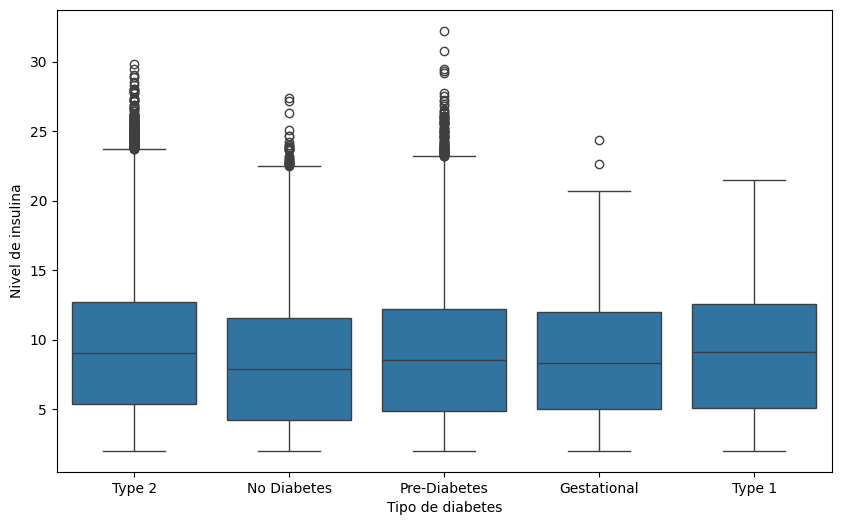

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='diabetes_stage',y='insulin_level')
plt.xlabel('Tipo de diabetes')
plt.ylabel('Nivel de insulina')
plt.show()

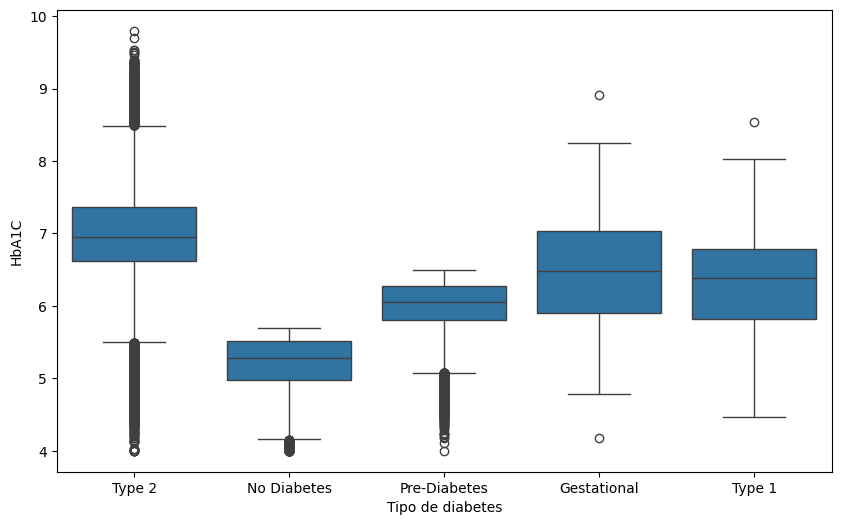

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='diabetes_stage',y='hba1c')
plt.xlabel('Tipo de diabetes')
plt.ylabel('HbA1C')
plt.show()

## Glucemia basal y postprandial

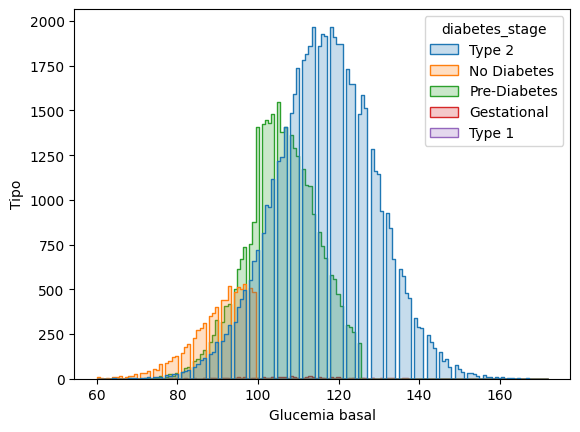

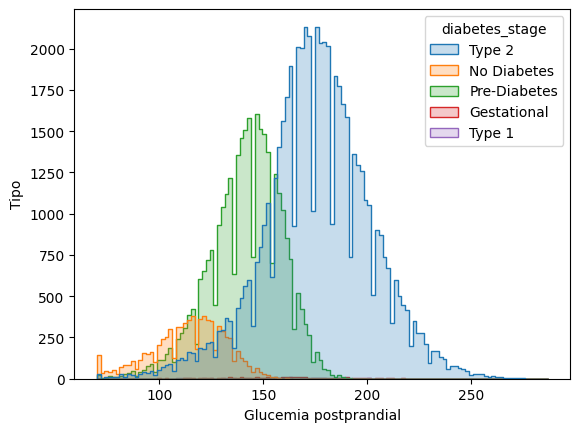

In [ ]:
sns.histplot(data=df, x='glucose_fasting', hue='diabetes_stage', element="step")
plt.xlabel('Glucemia basal')
plt.ylabel('Tipo')
plt.show()

sns.histplot(data=df, x='glucose_postprandial', hue='diabetes_stage', element="step")
plt.xlabel('Glucemia postprandial')
plt.ylabel('Tipo')
plt.show()

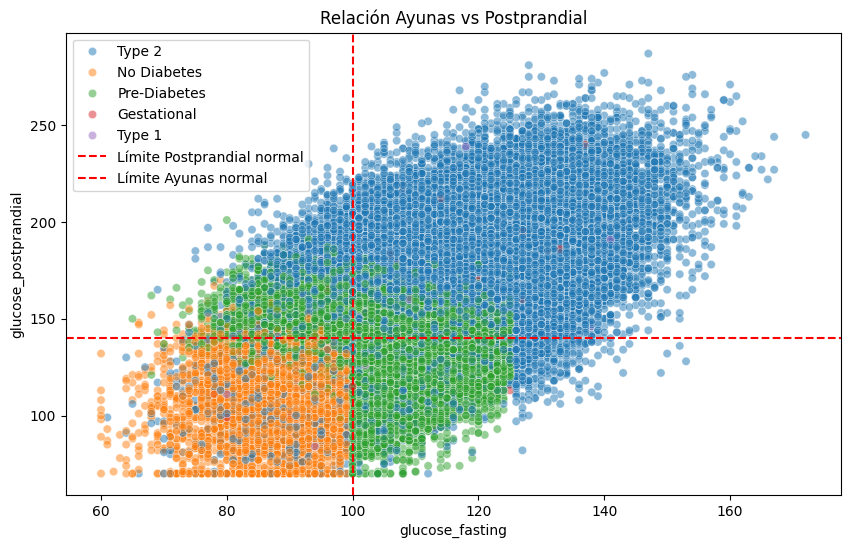

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='glucose_fasting', y='glucose_postprandial', hue='diabetes_stage', alpha=0.5)
plt.title('Relación Ayunas vs Postprandial')
plt.axhline(140, color='red', linestyle='--', label='Límite Postprandial normal')
plt.axvline(100, color='red', linestyle='--', label='Límite Ayunas normal')
plt.legend()
plt.show()

La gran parte del tipo 2 se concentra en el cuadrante negativo para ambas glucosas, la prediabentes en el centro y los no diabéticos en ambos cuadrados positivos. El resto de los tipos tiene pocos datos.

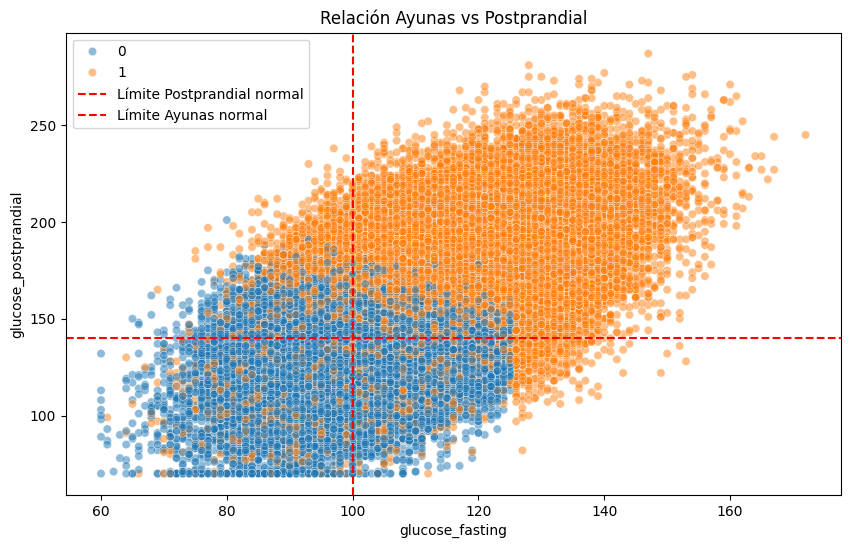

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='glucose_fasting', y='glucose_postprandial', hue='diagnosed_diabetes', alpha=0.5)
plt.title('Relación Ayunas vs Postprandial')
plt.axhline(140, color='red', linestyle='--', label='Límite Postprandial normal')
plt.axvline(100, color='red', linestyle='--', label='Límite Ayunas normal')
plt.legend()
plt.show()

Ocurre algo bastante parecido con el gráfico anterior. La mayoría de las personas con diabetes se concentra en los cuadrantes negativos para ambas diabetes y los que no la tienen en los positivos.

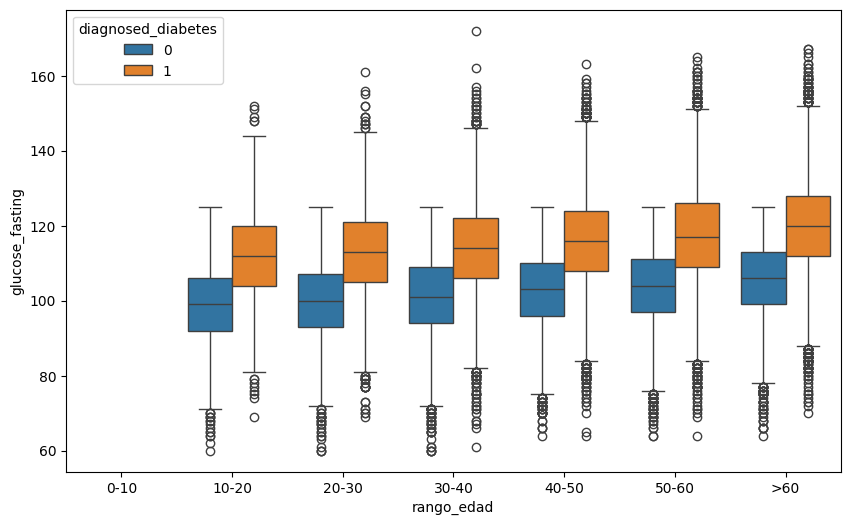

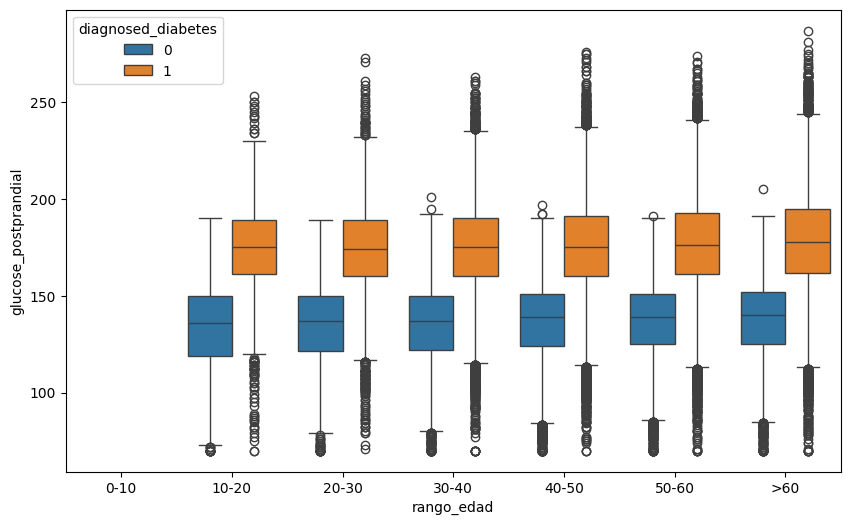

In [ ]:
df['rango_edad'] = pd.cut(df['age'], bins=[0,10,20,30,40,50,60,100], labels=['0-10','10-20','20-30','30-40','40-50','50-60','>60'])

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='rango_edad', y='glucose_fasting', hue='diagnosed_diabetes')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='rango_edad', y='glucose_postprandial', hue='diagnosed_diabetes')
plt.show()

**Glucemia basal (en ayunas)**  

Tanto en diabéticos como no diabéticos, la mediana de la glucosa en ayunas sube con la edad.


  
**Glucemia Postprandial**  

La mediana de glucosa se mantiene más constante con el paso de los años que en la glucemia en ayunas. Sin embargo, se ve una mayor diferencia entre los niveles de glucosa entre los diabéticos y no diabéticos en cualquier generación.


Por tanto, para ambas glucosas, aumenta ligeramente con la edad, mayormente la basal. Sin embargo, se confirma que los diabéticos gestionan peor la glucosa tras las comidas.



### Variación de los niveles de glucosa según la edad

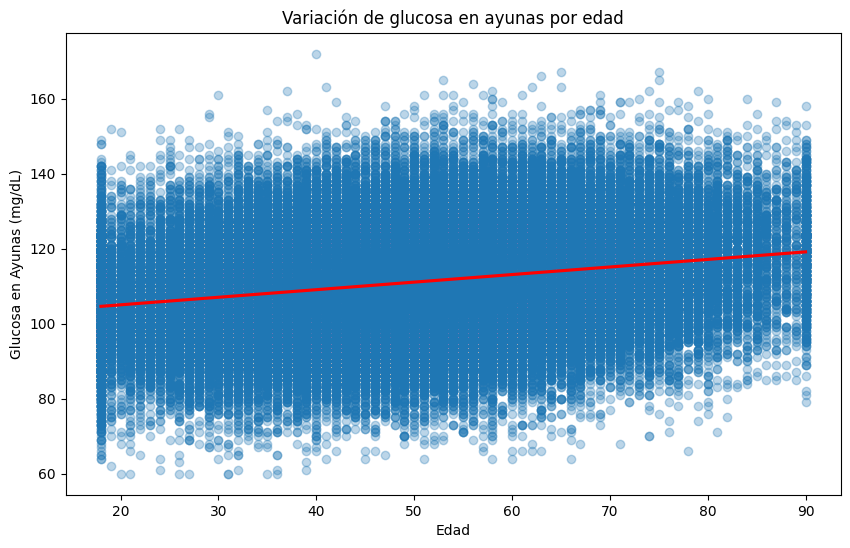

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='age', y='glucose_fasting',
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Variación de glucosa en ayunas por edad')
plt.xlabel('Edad')
plt.ylabel('Glucosa en Ayunas (mg/dL)')
plt.show()

Este gráfico tiene una línea de tendencia positiva, es decir, hay una relación directa entre las dos variables. La glucosa aumenta con la edad debido a varios factores. Entre ellos se encuentran la resistencia a la insulina, la reducción de la actividad física, cambios hormonales y de distribución de masa corporal.

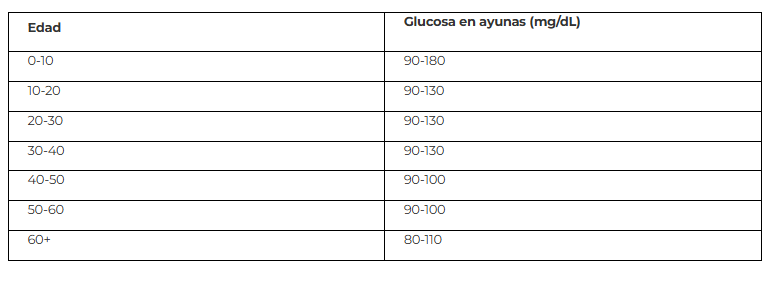

HbA1c es un factor predominante en la etapa de la diabetes.
* No diabetes: Concentrados mayoritariamente

<Axes: >

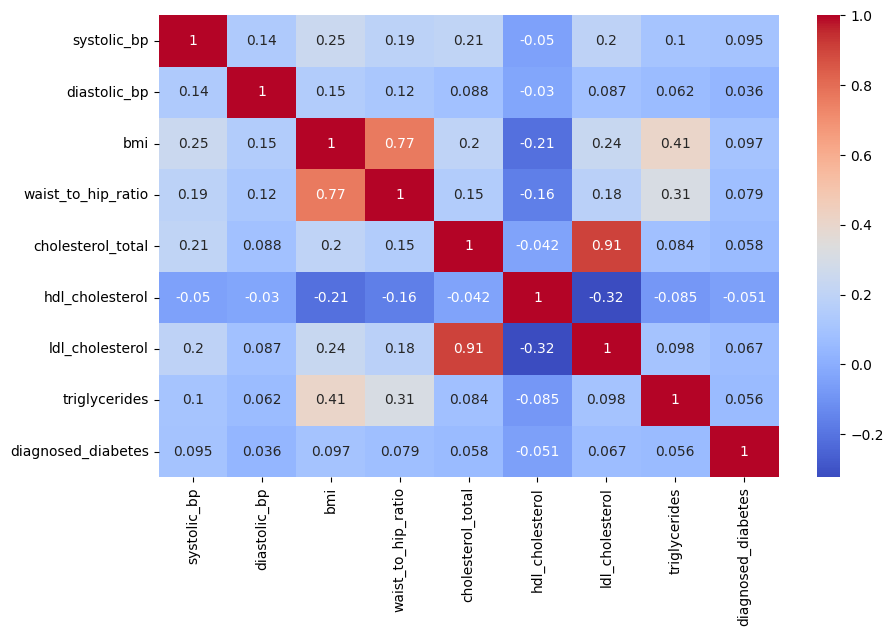

In [ ]:
meta = ['systolic_bp', 'diastolic_bp', 'bmi', 'waist_to_hip_ratio', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides','diagnosed_diabetes']

plt.figure(figsize=(10, 6))
sns.heatmap(df[meta].corr(), annot=True, cmap='coolwarm')

<Axes: >

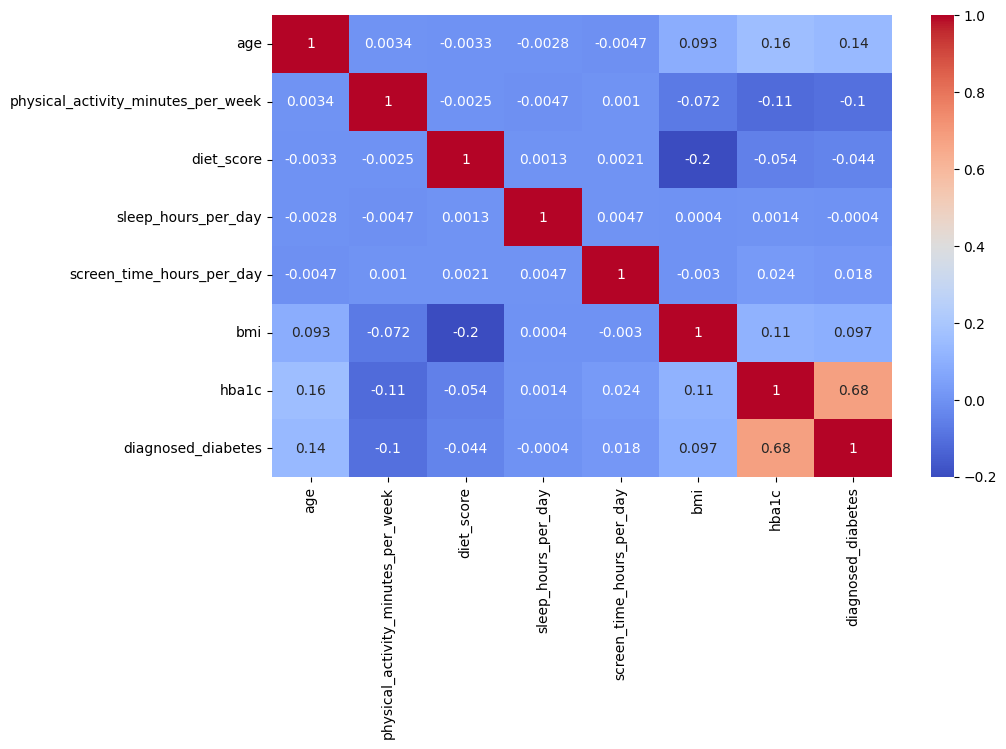

In [ ]:
estilo = ['age', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi', 'hba1c','diagnosed_diabetes']

plt.figure(figsize=(10, 6))
sns.heatmap(df[estilo].corr(), annot=True, cmap='coolwarm')

# Diabetes tipo 2 y estilo de vida
La diabetes tipo 2 es la resistencia a la insulina y está asociada a sobrepeso, sedentarismo y antecedentes familiares. Por contraste a la de tipo 1, la insulina no es el único tratamiento. La dieta y el ejercicio ayudan a controlar este tipo de diabetes.

<Axes: >

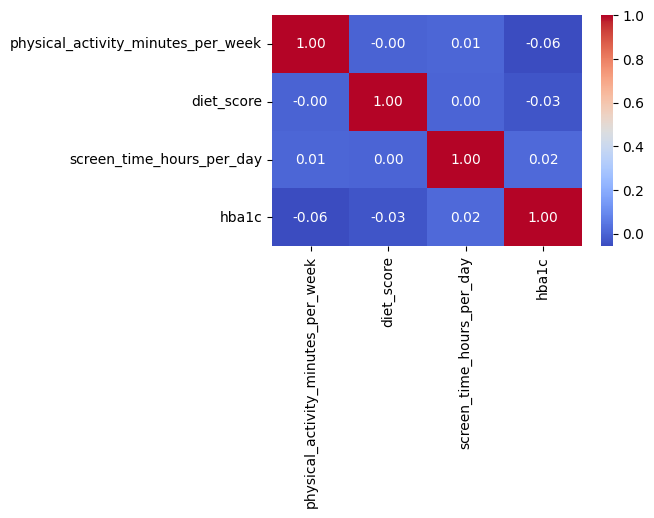

In [ ]:
estilo = ['physical_activity_minutes_per_week', 'diet_score', 'screen_time_hours_per_day', 'hba1c']

df_tipo2 = df[df['diabetes_stage'] == 'Type 2']

plt.figure(figsize=(5,3))
sns.heatmap(df_tipo2[estilo].corr(), annot=True, cmap='coolwarm', fmt=".2f")

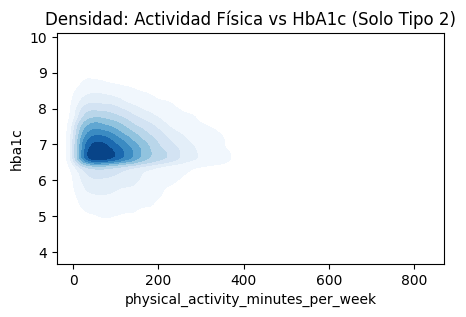

In [ ]:
plt.figure(figsize=(5,3))
sns.kdeplot(data=df_tipo2, x='physical_activity_minutes_per_week', y='hba1c', fill=True, cmap="Blues")
plt.title('Densidad: Actividad Física vs HbA1c (Solo Tipo 2)')
plt.show()

La mayoría de los pacientes de tipo 2 tienen un nivel de actividad bajo y mantienen una glicada en el límite.

In [ ]:
pearson_t2_act = df_tipo2['physical_activity_minutes_per_week'].corr(df_tipo2['hba1c'])
print(f"El coeficiente de correlación de Pearson es: {pearson_t2_act:.4f}")
spearman_t2_act = df_tipo2['physical_activity_minutes_per_week'].corr(df_tipo2['hba1c'], method='spearman')
print(f"El coeficiente de correlación de Spearman es: {spearman_t2_act:.4f}")

El coeficiente de correlación de Pearson es: -0.0576
El coeficiente de correlación de Spearman es: -0.0575


# Historial médico
A partir del describe(), sabemos el porcentaje de pacientes que tienen:
* Antecedentes de diabetes: 21.9%
* Historia de hipertensión: 25.08%
* Historia cardiovascular: 7.92%

<Axes: >

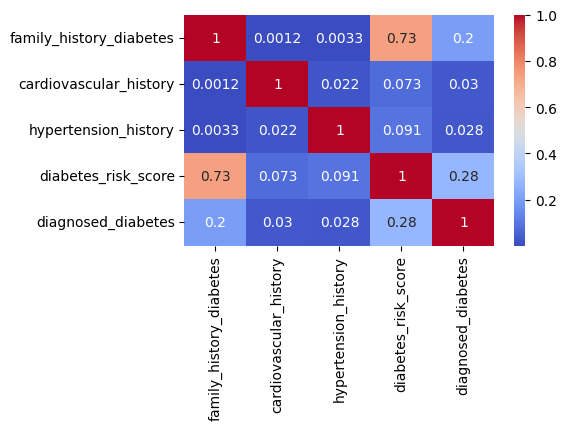

In [ ]:
antecedentes = ['family_history_diabetes', 'cardiovascular_history', 'hypertension_history', 'diabetes_risk_score', 'diagnosed_diabetes']

plt.figure(figsize=(5,3))
sns.heatmap(df[antecedentes].corr(), annot=True, cmap='coolwarm')

Se encuentra una alta correlación entre el puntuaje de riesgo de diabetes y un antecendente familiar de diabetes. Es altamente posible que uno de los factores por los que se ha calculado la el puntuaje sea a partir del antecedente familiar.  

No hay apenas relación entre antecendentes cardiovasculares y el desarrollo de la diabetes.

In [ ]:
ante_diab = pd.crosstab(df['family_history_diabetes'], df['diagnosed_diabetes'], normalize='index') * 100
ante_hiper = pd.crosstab(df['hypertension_history'], df['diagnosed_diabetes'], normalize='index') * 100
ante_cardio = pd.crosstab(df['cardiovascular_history'], df['diagnosed_diabetes'], normalize='index') * 100

print(ante_diab)
print(ante_hiper)
print(ante_cardio)

diagnosed_diabetes               0          1
family_history_diabetes                      
0                        45.142777  54.857223
1                        21.712775  78.287225
diagnosed_diabetes            0          1
hypertension_history                      
0                     40.782168  59.217832
1                     37.671451  62.328549
diagnosed_diabetes              0          1
cardiovascular_history                      
0                       40.430061  59.569939
1                       35.025253  64.974747


En el grupo de sin antecendentes de diabetes, la población está dividida casi a la mitad. En cambio, si el paciente tiene antecedentes, tendrá diabetes cerca de 8 de cada 10 veces. Al tener una historia de hipertensión o problemas cardiovasculares, baja a 6 de cada 10 veces.